![Grafos](EstrategiasInversión.png)


1. Obtener los datos de precios diarios para las 6 acciones y el S&P500 (usando librerías como 'yfinance').

¿Qué es el S&P500?

El S&P500 (Standard & Poor's 500) es un índice ponderado por capitalización de mercado que incluye las 500 compañías más grandes en EE. UU. y es ampliamente utilizado como un indicador del rendimiento general del mercado estadounidense

- **Open**: El precio de apertura de la acción en ese día.
- **High**: El precio más alto alcanzado por la acción durante ese día.
- **Low**: El precio más bajo alcanzado durante el día.
- **Close**: El precio de cierre de la acción al final del día de negociación.
- **Adj Close**: El precio de cierre ajustado por dividendos y divisiones de acciones (es un precio corregido).
- **Volume:** El volumen de acciones negociadas ese día.

In [119]:
import pandas as pd
import yfinance as yf

# Definir los símbolos de las acciones y el S&P500
acciones = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA', 'META']
indice_sp500 = '^GSPC'

# Descargar los datos de precios diarios
datos_acciones = yf.download(acciones, start='2024-01-01', end='2025-02-18')
print("-------------------------------------")
datos_sp500 = yf.download(indice_sp500, start='2024-01-01', end='2025-02-18')
dfAcciones=pd.DataFrame(datos_acciones)
dfIndices=pd.DataFrame(datos_sp500)


# Mostrar los primeros datos para comprobar
#dfAcciones['Volume'].head()
dfIndices.head()

[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  1 of 1 completed

-------------------------------------


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2024-01-02,4742.830078,4754.330078,4722.669922,4745.200195,3743050000
2024-01-03,4704.810059,4729.290039,4699.709961,4725.069824,3950760000
2024-01-04,4688.680176,4726.779785,4687.529785,4697.419922,3715480000
2024-01-05,4697.240234,4721.490234,4682.109863,4690.569824,3844370000
2024-01-08,4763.540039,4764.540039,4699.819824,4703.700195,3742320000


In [120]:
dfAcciones['Volume'].head()

Ticker,AAPL,AMZN,GOOGL,META,MSFT,TSLA
Date,,,,,,
2024-01-02,82488700,47339400,23711200,19042200,25258600,104654200
2024-01-03,58414500,49425500,24212100,15451100,23083500,121082600
2024-01-04,71983600,56039800,27137700,12099900,20901500,102629300
2024-01-05,62379700,45153100,22513900,13920700,21004600,92488900
2024-01-08,59144500,46757100,21404000,13890200,23134000,85166600


In [121]:
dfAcciones['Open'].head()


Ticker,AAPL,AMZN,GOOGL,META,MSFT,TSLA
Date,,,,,,
2024-01-02,185.225777,151.539993,137.414274,348.882923,367.528803,250.080002
2024-01-03,182.325900,149.199997,136.124926,342.586886,362.760965,244.979996
2024-01-04,180.277211,145.589996,137.285346,342.110276,364.392855,239.250000
2024-01-05,180.118838,144.690002,135.629029,344.583021,362.721619,236.860001
2024-01-08,180.217791,146.740005,135.172789,352.239506,363.046020,236.139999


In [122]:
dfAcciones['High'].head()


Ticker,AAPL,AMZN,GOOGL,META,MSFT,TSLA
Date,,,,,,
2024-01-02,186.502522,152.380005,138.306890,350.710156,369.534265,251.250000
2024-01-03,183.968836,151.050003,138.485421,345.536284,366.938993,245.679993
2024-01-04,181.207549,147.380005,138.019286,345.734951,366.781697,242.699997
2024-01-05,180.880911,146.589996,136.035672,351.047872,365.759287,240.119995
2024-01-08,183.691712,149.399994,137.870494,356.489815,368.846130,241.250000


In [123]:
dfAcciones['Low'].head()


Ticker,AAPL,AMZN,GOOGL,META,MSFT,TSLA
Date,,,,,,
2024-01-02,181.999301,148.389999,135.361235,337.651383,360.558873,244.410004
2024-01-03,181.544015,148.330002,135.956321,340.799354,362.269433,236.320007
2024-01-04,179.020279,144.050003,135.232322,341.017901,360.952126,237.729996
2024-01-05,178.317544,144.529999,134.042138,343.858104,360.293446,234.899994
2024-01-08,179.633861,146.149994,135.143036,349.607865,362.760953,235.300003


In [124]:
dfAcciones['Close'].head()


Ticker,AAPL,AMZN,GOOGL,META,MSFT,TSLA
Date,,,,,,
2024-01-02,183.731308,149.929993,137.037384,343.887817,364.589447,248.419998
2024-01-03,182.355591,148.470001,137.781235,342.080414,364.324036,238.449997
2024-01-04,180.039688,144.570007,135.271988,344.712097,361.709076,237.929993
2024-01-05,179.317154,145.240005,134.617386,349.508636,361.522278,237.490005
2024-01-08,183.652115,149.100006,137.701889,356.172028,368.344757,240.449997


# Ejercicio: Estrategia 1

**Lógica:** La cantidad de acciones de cada compañía se fija el primer día y permanece constante.  
**Pasos con Álgebra Lineal:**

1. Sea p₁ᵀ el primer vector fila de P (precios del día 1).  
 



In [125]:
# P: matriz de precios (filas = días, columnas = 6 acciones). Usamos Close.
P = dfAcciones['Close']

# p1 = vector fila = precios del día 1 (primera fila de P)
p1 = P.iloc[0]

# Opcional: p1 como array numpy 1d (fila) para operaciones vectoriales
p1 = P.iloc[0].values
p1 = P.iloc[[0]].values

print("Precios del Primer Día, estos son los precios con los cuales vamos a comprar las acciones:")
p1

Precios del Primer Día, estos son los precios con los cuales vamos a comprar las acciones:


array([[183.73130798, 149.92999268, 137.03738403, 343.88781738,
        364.58944702, 248.41999817]])

2. El capital asignado a cada acción es C/6.  
3. El vector de **número de acciones** q (en R⁶ˣ¹) se calcula elemento a elemento:  

qᵢ = (C/6) / p₁,ᵢ  →  q = (C/6) · (1/p₁)ᵀ

(donde la división es elemento a elemento). 

In [126]:
C = dfIndices["Close"].iloc[0].values[0]
print(f"El capital invertido será de: {C}")

El capital invertido será de: 4742.830078125


In [127]:



# Capital por acción = C/6. Vector de cantidades q (columna 6×1): q_i = (C/6) / p₁,ᵢ
# p1 está como fila (1×6), hacemos la división elemento a elemento y pasamos a columna
q = (C/6)*(1/p1.reshape(-1,1))
q
for cantidadAcciones in q:
    print(f"Vamos a comprar {cantidadAcciones}")


Vamos a comprar [4.30232435]
Vamos a comprar [5.27227185]
Vamos a comprar [5.76829225]
Vamos a comprar [2.2986324]
Vamos a comprar [2.16811454]
Vamos a comprar [3.18199696]


5. El vector de **riqueza acumulada** W⁽¹⁾ (en Rᵀˣ¹) se calcula de forma compacta con una única multiplicación matriz-vector:  

W⁽¹⁾ = P · q

In [128]:
PreciosH=dfAcciones['Close'].values 
PreciosH

array([[183.73130798, 149.92999268, 137.03738403, 343.88781738,
        364.58944702, 248.41999817],
       [182.35559082, 148.47000122, 137.78123474, 342.08041382,
        364.32403564, 238.44999695],
       [180.03968811, 144.57000732, 135.27198792, 344.71209717,
        361.70907593, 237.92999268],
       ...,
       [235.84208679, 228.92999268, 182.76504517, 723.09985352,
        405.12002563, 336.51000977],
       [240.4818573 , 230.36999512, 185.28340149, 726.26989746,
        406.60565186, 355.94000244],
       [243.53857422, 228.67999268, 184.37759399, 734.35430908,
        404.51583862, 355.83999634]], shape=(282, 6))

In [129]:
PreciosH=dfAcciones['Close'].values 
W=PreciosH@q
print(W)

[[4742.83007812]
 [4697.05006084]
 [4650.77548761]
 [4656.64383089]
 [4752.96481414]
 [4757.28339044]
 [4823.20372141]
 [4807.90484145]
 [4802.29944536]
 [4774.97039359]
 [4743.94363682]
 [4805.6298608 ]
 [4872.32439965]
 [4857.85904156]
 [4889.87934328]
 [4917.1494283 ]
 [4868.9180082 ]
 [4872.68058905]
 [4941.06002394]
 [4899.204927  ]
 [4738.88674736]
 [4805.73855785]
 [5070.40833544]
 [5008.49652702]
 [5013.49023612]
 [5089.55222272]
 [5090.75362461]
 [5158.19184413]
 [5104.62737017]
 [5010.2761175 ]
 [5076.72979738]
 [5106.77569235]
 [5054.38877797]
 [5015.82005536]
 [5029.7556506 ]
 [5148.8696161 ]
 [5117.49398602]
 [5086.19783088]
 [5106.74181833]
 [5086.21579245]
 [5140.33333179]
 [5170.03157884]
 [5068.76416406]
 [4957.43947593]
 [4941.54780777]
 [5034.09408852]
 [5008.58597209]
 [4965.26190682]
 [5049.31235309]
 [5018.3245769 ]
 [5047.63336574]
 [4979.14974729]
 [5085.24818511]
 [5098.22949689]
 [5174.08979299]
 [5141.3666815 ]
 [5163.65944013]
 [5136.16807516]
 [5124.4668722

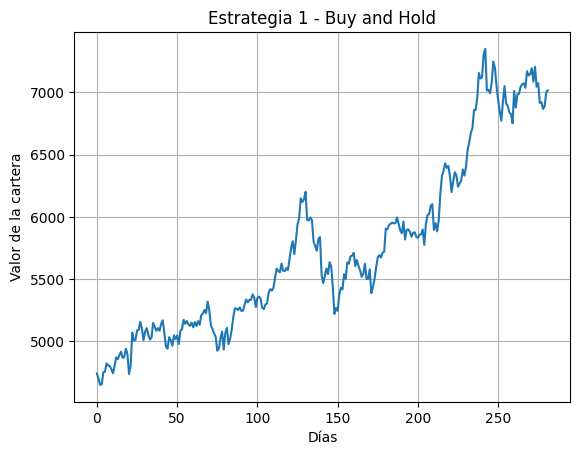

In [130]:
import matplotlib.pyplot as plt
plt.plot(W)
plt.title("Estrategia 1 - Buy and Hold")
plt.xlabel("Días")
plt.ylabel("Valor de la cartera")
plt.grid(True)
plt.show()

# Ejercicio: Estrategia 2

**Lógica:** La *proporción* de la riqueza en cada acción es constante, no la cantidad de acciones.  
**Pasos con Álgebra Lineal:**

1. El vector de **pesos** (weights) es constante:
   
   $$\mathbf{w} = \frac{1}{6} (1, 1, 1, 1, 1, 1)^\top$$

2. Se necesita la matriz de **retornos simples diarios**
   
   $$\mathbf{R} \in \mathbb{R}^{(T-1) \times 6}$$
   
   donde
   
   $$R_{t,i} = \frac{P_{t+1,i} - P_{t,i}}{P_{t,i}}$$

3. El retorno de la cartera en el día $t$ es el producto punto del vector de pesos con el vector de retornos de ese día ($\mathbf{r}_t^\top$, la fila $t$ de $\mathbf{R}$):
   
   $$r_t^{(p)} = \mathbf{w}^\top \mathbf{r}_t$$

4. La riqueza acumulada $\mathbf{W}^{(2)}$ se calcula de forma iterativa:
   
   $$W_1^{(2)} = C, \quad W_{t+1}^{(2)} = W_t^{(2)} \cdot (1 + r_t^{(p)})$$
   
   Esto se puede expresar como un producto acumulado. Aunque no es una sola multiplicación matricial, cada paso se basa en un producto punto.

1. El vector de **pesos** (weights) es constante:
   
   $$\mathbf{w} = \frac{1}{6} (1, 1, 1, 1, 1, 1)^\top$$

In [131]:
import numpy as np
import matplotlib.pyplot as plt
w2 = np.ones(6) / 6
P = dfAcciones['Close'].values
w2

array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
       0.16666667])

2. Se necesita la matriz de **retornos simples diarios**
   
   $$\mathbf{R} \in \mathbb{R}^{(T-1) \times 6}$$
   
   donde
   
   $$R_{t,i} = \frac{P_{t+1,i} - P_{t,i}}{P_{t,i}}$$

In [132]:
R = (P[1:] - P[:-1]) / P[:-1]
R

array([[-0.00748766, -0.00973782,  0.00542809, -0.00525579, -0.00072797,
        -0.04013365],
       [-0.01269993, -0.02626789, -0.01821182,  0.00769317, -0.00717757,
        -0.00218077],
       [-0.00401319,  0.00463442, -0.00483915,  0.01391462, -0.00051643,
        -0.00184923],
       ...,
       [ 0.01827005, -0.01645473, -0.00922738,  0.0077523 , -0.00583321,
         0.02438359],
       [ 0.01967321,  0.00629014,  0.0137792 ,  0.00438396,  0.00366713,
         0.05773972],
       [ 0.0127108 , -0.00733604, -0.00488877,  0.01113141, -0.00513966,
        -0.00028096]], shape=(281, 6))


3. El retorno de la cartera en el día $t$ es el producto punto del vector de pesos con el vector de retornos de ese día ($\mathbf{r}_t^\top$, la fila $t$ de $\mathbf{R}$):
   
   $$r_t^{(p)} = \mathbf{w}^\top \mathbf{r}_t$$

In [133]:
rp = R @ w2
rp


array([-9.65246836e-03, -9.80746663e-03,  1.22183910e-03,  2.06774742e-02,
        8.05441716e-04,  1.35690148e-02, -3.53688474e-03, -1.90953188e-03,
       -5.39333753e-03, -6.86645431e-03,  1.23190879e-02,  1.34738564e-02,
       -3.30927446e-03,  6.41180880e-03,  5.07388035e-03, -1.39892610e-02,
        8.82243537e-04,  1.53726555e-02, -8.05154705e-03, -3.20744231e-02,
        1.38441911e-02,  4.97460814e-02, -1.20921729e-02,  2.74231291e-03,
        1.43237249e-02,  7.19081094e-04,  1.41832657e-02, -1.16596252e-02,
       -1.85072506e-02,  1.30551500e-02,  7.92886837e-03, -9.44474108e-03,
       -8.59951125e-03,  3.37033353e-03,  2.22251385e-02, -7.27446085e-03,
       -4.36253776e-03,  3.89280017e-03, -3.48049975e-03,  9.78330505e-03,
        4.29787222e-03, -2.29569489e-02, -2.29878343e-02, -5.26805044e-03,
        1.71641183e-02, -4.70990134e-03, -4.22189695e-03,  1.45793628e-02,
       -8.38892862e-03,  3.77628983e-03, -1.16108256e-02,  2.40110093e-02,
        1.89413477e-03,  

4. La riqueza acumulada $\mathbf{W}^{(2)}$ se calcula de forma iterativa:
   
   $$W_1^{(2)} = C, \quad W_{t+1}^{(2)} = W_t^{(2)} \cdot (1 + r_t^{(p)})$$
   
   Esto se puede expresar como un producto acumulado. Aunque no es una sola multiplicación matricial, cada paso se basa en un producto punto.

In [134]:
W2 = np.zeros(len(rp)+1)
W2[0] = C

for t in range(len(rp)):
    W2[t+1] = W2[t] * (1 + rp[t])
W2

array([4742.83007812, 4697.05006084, 4650.9838991 , 4656.66665309,
       4752.95475759, 4756.78298563, 4821.32784422, 4804.27536333,
       4795.10144635, 4769.23984575, 4736.49207826, 4794.84134033,
       4859.44634407, 4843.36510238, 4874.41983337, 4899.15205639,
       4830.6165395 , 4834.87831972, 4909.2032387 , 4869.67655785,
       4713.48449166, 4778.73887151, 5016.46240433, 4955.80247382,
       4969.39283494, 5040.57305064, 5044.19763142, 5115.74082675,
       5056.09320625, 4962.518822  , 5027.30524954, 5067.16609114,
       5019.30801939, 4976.1444236 , 4992.91569002, 5103.8839325 ,
       5066.75592864, 5044.65201459, 5064.28983681, 5046.66357727,
       5096.03662655, 5117.9387408 , 5000.44648263, 4885.49704739,
       4859.7600025 , 4943.17349812, 4919.89163864, 4899.12036312,
       4970.54641642, 4928.84885731, 4947.46161912, 4890.017505  ,
       5007.43176101, 5016.91651162, 5094.03358989, 5051.1402343 ,
       5069.18181736, 5048.65307988, 5050.03216838, 5082.57372

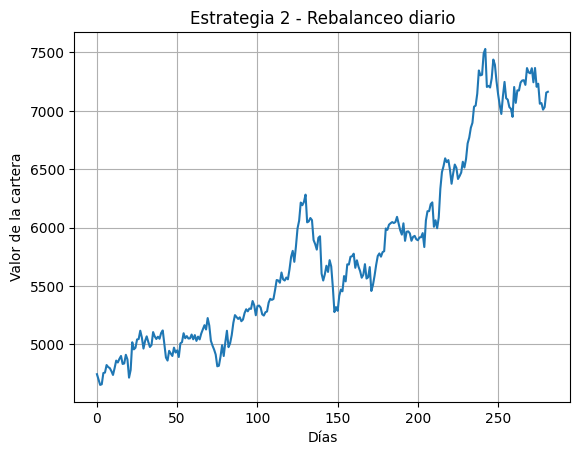

In [135]:
plt.plot(W2)
plt.title("Estrategia 2 - Rebalanceo diario")
plt.xlabel("Días")
plt.ylabel("Valor de la cartera")
plt.grid(True)
plt.show()

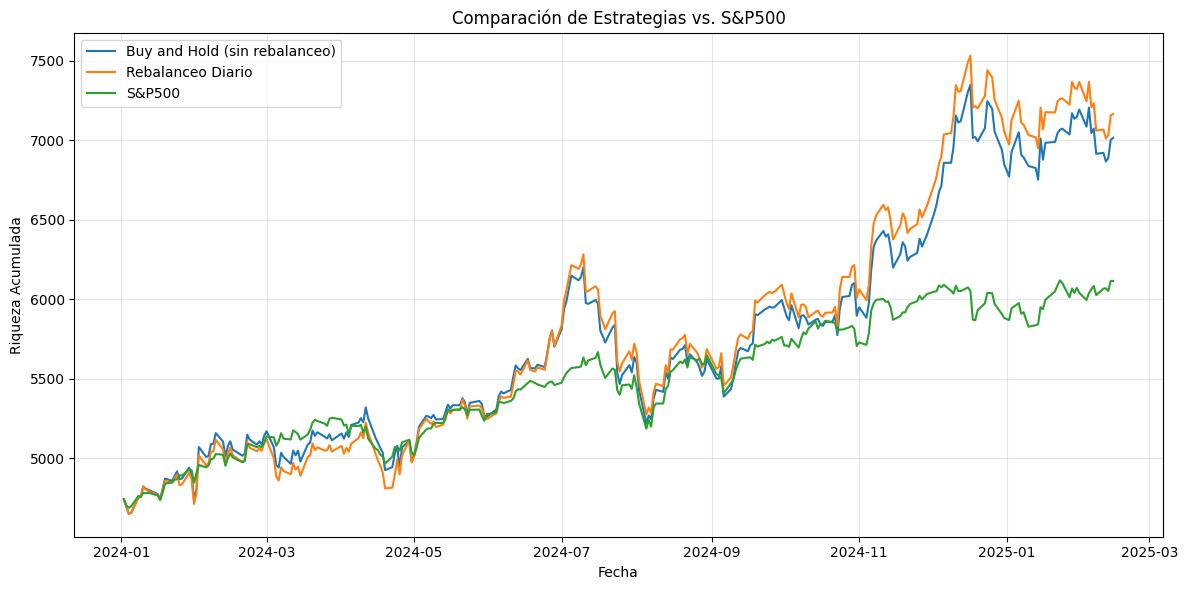

In [136]:

fechas = dfAcciones["Close"].index

# S&P500 normalizado al capital inicial C (misma escala que las carteras)
sp500_close = dfIndices["Close"].squeeze() if hasattr(dfIndices["Close"], "squeeze") else dfIndices["Close"].iloc[:, 0]
sp500_norm = (sp500_close / sp500_close.iloc[0]) * C
# Alinear fechas por si hubiera días distintos
sp500_plot = sp500_norm.reindex(fechas).ffill().bfill()

plt.figure(figsize=(12, 6))
plt.plot(fechas, W, label="Buy and Hold (sin rebalanceo)", color="C0")
plt.plot(fechas, W2, label="Rebalanceo Diario", color="C1")
plt.plot(fechas, sp500_plot, label="S&P500", color="C2")
plt.title("Comparación de Estrategias vs. S&P500")
plt.xlabel("Fecha")
plt.ylabel("Riqueza Acumulada")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Grafos como matices

1. Matriz de Adyacencia

![Grafos](Grafos.png)

In [137]:
import numpy as np
import pandas as pd
Grafo1=[[0,1,1,0,0,1],
[1,0,0,1,1,0],
[1,0,0,0,1,1],
[0,1,0,0,0,1],
[0,1,1,0,0,1],
[1,0,1,1,1,0]]

GradoGrafo1=np.sum(Grafo1,axis=0)
MatrizGradoG1=[]
for i in range(len(GradoGrafo1)):
    MatrizGradoG1.append([])
    for j in range(len(GradoGrafo1)):
        if i==j:
            MatrizGradoG1[i].append(GradoGrafo1[i])
        else:
            MatrizGradoG1[i].append(0)

MatrizGradoG1

Grafo2 = np.array([
    [0,1,1,0,0,0,0,0],  # v1
    [1,0,0,1,1,0,0,0],  # v2
    [1,0,0,0,0,1,1,0],  # v3
    [0,1,0,0,0,0,0,1],  # v4
    [0,1,0,0,0,0,0,1],  # v5
    [0,0,1,0,0,0,1,0],  # v6
    [0,0,1,0,0,1,0,1],  # v7
    [0,0,0,1,1,0,1,0]   # v8
])
GradoG2=np.sum(Grafo2,axis=0)
MatrizGradoG2=[]
for i in range(len(GradoG2)):
    MatrizGradoG2.append([])
    for j in range(len(GradoG2)):
        if i==j:
            MatrizGradoG2[i].append(GradoG2[i])
        else:
            MatrizGradoG2[i].append(0)

df1=pd.DataFrame(MatrizGradoG1)
df2=pd.DataFrame(MatrizGradoG2)
df1.columns=["v1","v2","v3","v4","v5","v6"]
df1.index=["v1","v2","v3","v4","v5","v6"]

df2.columns=["v1","v2","v3","v4","v5","v6","v7","v8"]
df2.index=["v1","v2","v3","v4","v5","v6","v7","v8"]
print(df1)  
print("--------------------------------")
print(df2)

    v1  v2  v3  v4  v5  v6
v1   3   0   0   0   0   0
v2   0   3   0   0   0   0
v3   0   0   3   0   0   0
v4   0   0   0   2   0   0
v5   0   0   0   0   3   0
v6   0   0   0   0   0   4
--------------------------------
    v1  v2  v3  v4  v5  v6  v7  v8
v1   2   0   0   0   0   0   0   0
v2   0   3   0   0   0   0   0   0
v3   0   0   3   0   0   0   0   0
v4   0   0   0   2   0   0   0   0
v5   0   0   0   0   2   0   0   0
v6   0   0   0   0   0   2   0   0
v7   0   0   0   0   0   0   3   0
v8   0   0   0   0   0   0   0   3


![Grafos](MatrizAdyacencia.png)

1. Dibuje Grafo
2. Calcule el grado del vertice


![Grafos](DibujoGrafo.png)

In [138]:
Grafo3 = np.array([
    [0, 1, 0, 1, 0, 0],
    [1, 0, 1, 1, 0, 0],
    [0, 1, 0, 0, 1, 1],
    [1, 1, 0, 0, 1, 0],
    [0, 0, 1, 1, 0, 1],
    [0, 0, 1, 0, 1, 0]
])

GradoG3=np.sum(Grafo3,axis=0)
MatrizGradoG3=[]
for i in range(len(GradoG3)):
    MatrizGradoG3.append([])
    for j in range(len(GradoG3)):
        if i==j:
            MatrizGradoG3[i].append(GradoG3[i])
        else:
            MatrizGradoG3[i].append(0)


i=0
j=0
mayor={}#posicion y grado
while i<len(Grafo3):
    while j<len(Grafo3):
            posicion=i+1
            grado=MatrizGradoG3[i][j]
            mayor[posicion]=grado
            j+=1
            i+=1


df3=pd.DataFrame(MatrizGradoG3)
df3.columns=["v1","v2","v3","v4","v5","v6"]
df3.index=["v1","v2","v3","v4","v5","v6"]
print(df3)
maximo=max(mayor.values())
aux=mayor.copy()
for key,value in aux.items():
    if value==maximo:
        print(f"El nodo {key} es uno de los mayores con {value} aristas")
       




        










    v1  v2  v3  v4  v5  v6
v1   2   0   0   0   0   0
v2   0   3   0   0   0   0
v3   0   0   3   0   0   0
v4   0   0   0   3   0   0
v5   0   0   0   0   3   0
v6   0   0   0   0   0   2
El nodo 2 es uno de los mayores con 3 aristas
El nodo 3 es uno de los mayores con 3 aristas
El nodo 4 es uno de los mayores con 3 aristas
El nodo 5 es uno de los mayores con 3 aristas


Grafos como matices

1. Matriz de Adyacencia

![Grafos](Ecuaciones.png)

Al hacer la matriz que con respecto a las ecuaciones queda de la siguiente forma:
[[1,1,1]
[1,-1,2]
[2,0,3]]
Que resulta ser una matriz **singular** que quiere decir que no tiene inversa, esto pasa cunaod las filas son linealmente dependientes, entonces se podría expresar como una combinacion lineal de otra fila

Si det(A)=0, entonces es una matriz singular


In [139]:
import numpy as np
A = np.array([[1,1,1],[1,-1,2],[2,0,3]])
b = np.array([3,-2,1])

#Verificamos si es singular
det_A = np.linalg.det(A)
print(f"Determinante de A: {det_A}")

#Si det(A)=0, entonces es singular
if det_A == 0:
    print("La matriz es singular")
else:
    print("La matriz no es singular")   

Determinante de A: 0.0
La matriz es singular


Como es una matriz singular no nos sirve la función  "np.linalg.solve(A, b)"

Es por eso que debemos utilizar la solición de Mínimos cuadrados

In [140]:
solucion = np.linalg.lstsq(A, b, rcond=None)[0]
print(f"Solución: {solucion}")

Solución: [ 0.71428571  2.42857143 -0.14285714]


![Grafos](Comunas.png)

In [143]:
import numpy as np
A = np.array([[0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1], # 01 Popular
     [1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # 02 Santa Cruz
     [1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1], # 03 Manrique
     [1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # 04 Aranjuez
     [0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # 05 Castilla
     [0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0], # 06 12 de Octubre
     [0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0], # 07 Robledo
     [0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1], # 08 Villa Hermosa
     [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1], # 09 Buenos Aires
     [0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0], # 10 La Candelaria
     [0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0], # 11 Laureles-Estadio
     [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0], # 12 La Ameria
     [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0], # 13 San Javier
     [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1], # 14 Poblado
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0], # 15 Guayabal
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0], # 16 Belen
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0], # 50 Palmitas
     [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0], # 60 San Cristobal
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0], # 70 Altavista
     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0], # 80 Prado
     [1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], # 90 Santa Elena
     ])
A

array([[0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

![Grafos](Homicidios.png)

In [145]:
homicidios = [
    15,  # 01 Popular
    7,   # 02 Santa Cruz
    28,  # 03 Manrique
    25,  # 04 Aranjuez
    13,  # 05 Castilla
    9,   # 06 Doce de Octubre
    17,  # 07 Robledo
    18,  # 08 Villa Hermosa
    9,   # 09 Buenos Aires
    66,  # 10 La Candelaria
    21,  # 11 Laureles Estadio
    6,   # 12 La América
    21,  # 13 San Javier
    4,   # 14 El Poblado
    8,   # 15 Guayabal
    18,  # 16 Belén
    5,   # 50 San Sebastián de Palmitas
    8,   # 60 San Cristóbal
    6,   # 70 Altavista
    8,   # 80 San Antonio de Prado
    5    # 90 Santa Elena
]

In [146]:
hi=np.array(homicidios)
h_gorro=np.mean(hi)
Sh=np.std(hi)
H_i_gorro=(hi-h_gorro)/Sh
print("Promedio de hurtos por comuna/corregimiento: ",h_gorro)
print(f"Indicador estandarizado de hurtos por comuna/corregimiento: {H_i_gorro}")

print(len(A))

Promedio de hurtos por comuna/corregimiento:  15.095238095238095
Indicador estandarizado de hurtos por comuna/corregimiento: [-0.0071424  -0.60710414  0.96779542  0.74280977 -0.15713284 -0.45711371
  0.14284803  0.21784325 -0.45711371  3.81761368  0.4428289  -0.68209936
  0.4428289  -0.83208979 -0.53210892  0.21784325 -0.75709457 -0.53210892
 -0.68209936 -0.53210892 -0.75709457]
21


In [147]:
# Crear matriz de pesos W como array de NumPy
W = np.zeros((len(A), len(A)), dtype=np.float64)
sigma = 1

for i in range(len(A)):
    for j in range(len(A)):
        if A[i,j] == 1: 
            diferencia = H_i_gorro[i] - H_i_gorro[j]
            # Fórmula correcta: exp(-((h_i - h_j)^2) / (2 * sigma^2))
            W[i,j] = np.exp(-(diferencia**2) / (2 * sigma**2))
        else:
            W[i,j] = 0

print(f"Número de aristas con peso no cero: {np.count_nonzero(W)}")
print("\nMatriz de pesos W:")
print(W)

Número de aristas con peso no cero: 92

Matriz de pesos W:
[[0.00000000e+00 8.35289386e-01 6.21728435e-01 7.54866678e-01
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  7.54866678e-01]
 [8.35289386e-01 0.00000000e+00 0.00000000e+00 4.02068107e-01
  9.03718747e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [6.21728435e-01 0.00000000e+00 0.00000000e+00 9.75008323e-01
  0.00000000e+00 0.00000000e+00 0.00000000e+00 7.54866678e-01
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.000

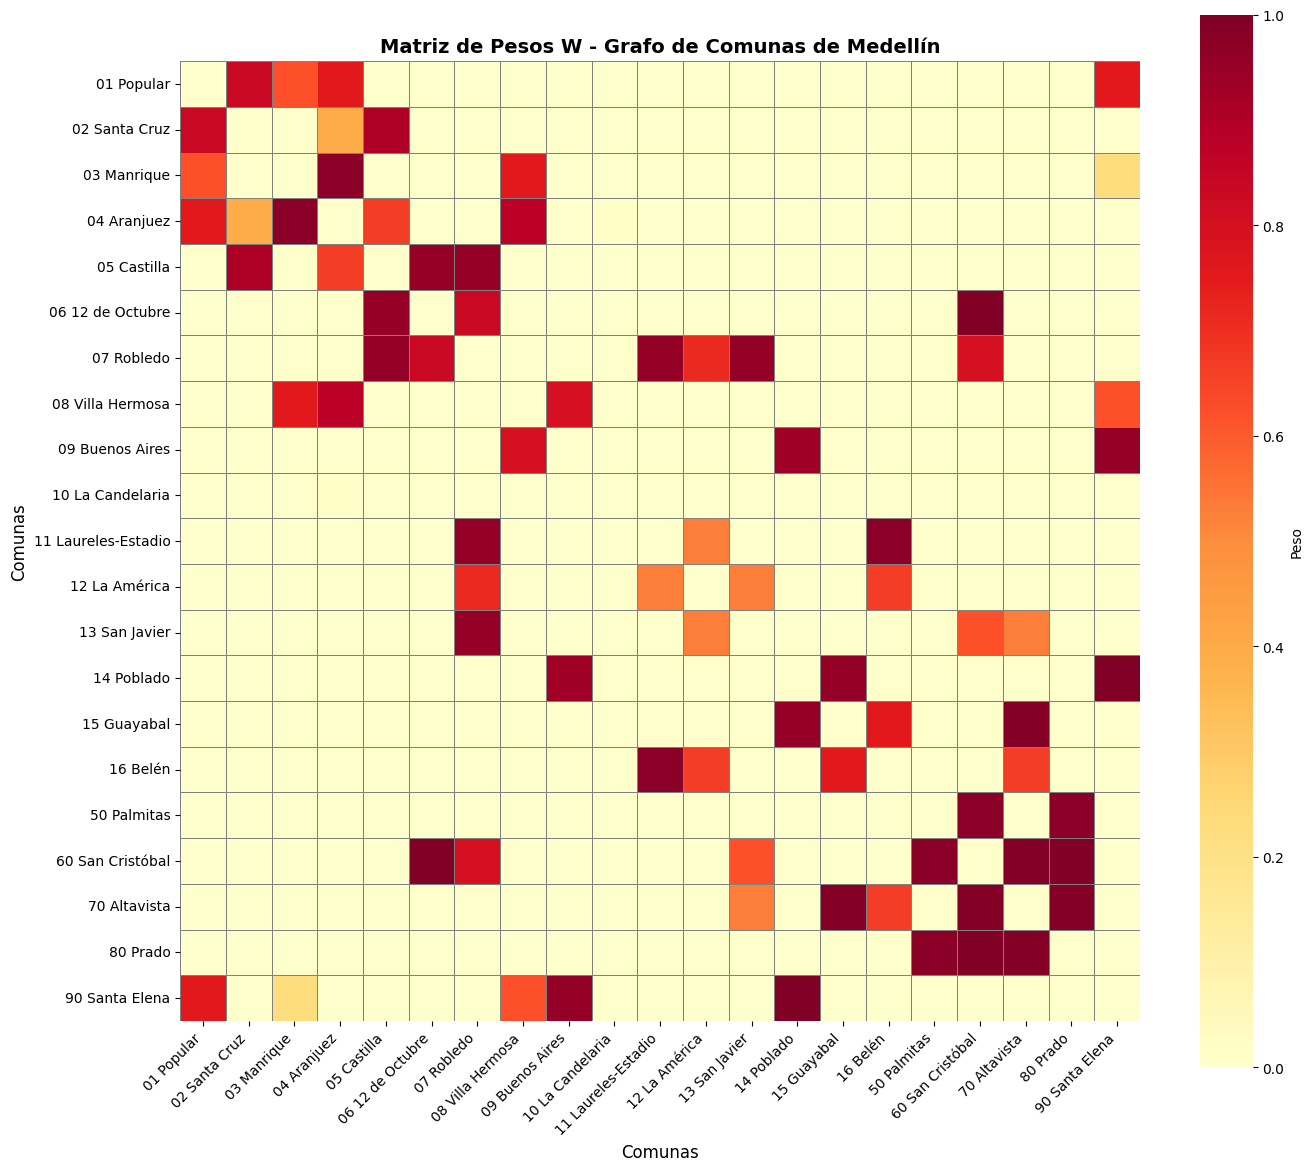

In [148]:
# Visualización gráfica con heatmap
import matplotlib.pyplot as plt
import seaborn as sns

# Nombres de las comunas
comunas = [
    "01 Popular", "02 Santa Cruz", "03 Manrique", "04 Aranjuez", "05 Castilla",
    "06 12 de Octubre", "07 Robledo", "08 Villa Hermosa", "09 Buenos Aires", "10 La Candelaria",
    "11 Laureles-Estadio", "12 La América", "13 San Javier", "14 Poblado", "15 Guayabal",
    "16 Belén", "50 Palmitas", "60 San Cristóbal", "70 Altavista", "80 Prado", "90 Santa Elena"
]

# Configurar estilo
plt.figure(figsize=(14, 12))
sns.heatmap(W, 
            annot=False,  # Cambiar a True si quieres ver los valores en cada celda
            fmt='.3f',
            cmap='YlOrRd',  # Colormap: puedes usar 'viridis', 'plasma', 'coolwarm', etc.
            cbar_kws={'label': 'Peso'},
            square=True,
            linewidths=0.5,
            linecolor='gray',
            xticklabels=comunas,
            yticklabels=comunas,
            vmin=0,
            vmax=1)

plt.title('Matriz de Pesos W - Grafo de Comunas de Medellín', fontsize=14, fontweight='bold')
plt.xlabel('Comunas', fontsize=12)
plt.ylabel('Comunas', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [149]:
D=np.diag(np.sum(W,axis=1))
D_inv_sqrt = np.diag(1 / np.sqrt(np.diag(D)))
L = np.eye(len(W)) - D_inv_sqrt @ W @ D_inv_sqrt
L

array([[ 1.00000000e+00, -3.31421238e-01, -2.24832857e-01,
        -2.28486165e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -2.32416631e-01],
       [-3.31421238e-01,  1.00000000e+00,  0.00000000e+00,
        -1.43256315e-01, -3.30945859e-01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-2.24832857e-01,  0.00000000e+00,  1.00000000e+00,
        -3.16619857e-01,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -2.69417624e-01,  0.00000000e

In [150]:
vals, vecs = np.linalg.eig(L)
idx = np.argsort(vals)
#print(vals)
#print(idx)
val2=vals[idx[1]]
fiedler=vecs[:,idx[1]]
print(fiedler)

Grupo1=np.where(fiedler<0)[0]
Grupo2=np.where(fiedler>=0)[0]

print(Grupo1)
print(Grupo2)

Comunas=[
    "01 Popular",
    "02 Santa Cruz",
    "03 Manrique",
    "04 Aranjuez",
    "05 Castilla",
    "06 12 de Octubre",
    "07 Robledo",
    "08 Villa Hermosa",
    "09 Buenos Aires",
    "10 La Candelaria",
    "11 Laureles-Estadio",
    "12 La América",
    "13 San Javier",
    "14 Poblado",
    "15 Guayabal",
    "16 Belén",
    "50 Palmitas",
    "60 San Cristóbal",
    "70 Altavista",
    "80 Prado",
    "90 Santa Elena",
]
print([Comunas[i] for i in Grupo1])
print([Comunas[i] for i in Grupo2])






[ 0.28174995  0.15571036  0.28996891  0.29077364  0.02197087 -0.12348456
 -0.21282415  0.31828364  0.27526333  0.00863421 -0.17072674 -0.17651869
 -0.19032565  0.1912832  -0.0491696  -0.17255323 -0.19676723 -0.28337768
 -0.22102252 -0.23304577  0.31948768]
[ 5  6 10 11 12 14 15 16 17 18 19]
[ 0  1  2  3  4  7  8  9 13 20]
['06 12 de Octubre', '07 Robledo', '11 Laureles-Estadio', '12 La América', '13 San Javier', '15 Guayabal', '16 Belén', '50 Palmitas', '60 San Cristóbal', '70 Altavista', '80 Prado']
['01 Popular', '02 Santa Cruz', '03 Manrique', '04 Aranjuez', '05 Castilla', '08 Villa Hermosa', '09 Buenos Aires', '10 La Candelaria', '14 Poblado', '90 Santa Elena']


In [151]:
# Autovalores de L (Laplaciana normalizada) y selección de k con spectral gap
import numpy as np
from sklearn.cluster import KMeans

# Como L es simétrica, usamos eigh (autovalores reales y ordenados crecientes)
eigvals, eigvecs = np.linalg.eigh(L)

print("Autovalores de L (ordenados):")
print(eigvals)

# Gaps \lambda_{i+1} - \lambda_i
gaps = eigvals[1:] - eigvals[:-1]
print("\nGaps (lambda[i+1] - lambda[i]):")
print(gaps)

# Elegimos k como el índice del mayor gap (ignorando el primero si se desea)
# Aquí usamos todos los gaps; puedes restringir el rango si hace sentido.
k = np.argmax(gaps) + 1  # +1 porque el gap entre lambda_k y lambda_{k-1}
print(f"\nNúmero de clusters sugerido por spectral gap: k = {k}")

Autovalores de L (ordenados):
[-1.05964499e-15  8.60965012e-02  2.77694576e-01  3.37800117e-01
  5.52037377e-01  6.31675740e-01  8.13729946e-01  8.56314317e-01
  9.98961145e-01  1.03473625e+00  1.09304079e+00  1.20466756e+00
  1.25736219e+00  1.34215229e+00  1.36085693e+00  1.38874524e+00
  1.43626883e+00  1.48417644e+00  1.55537081e+00  1.63089938e+00
  1.65741357e+00]

Gaps (lambda[i+1] - lambda[i]):
[0.0860965  0.19159807 0.06010554 0.21423726 0.07963836 0.18205421
 0.04258437 0.14264683 0.0357751  0.05830454 0.11162678 0.05269463
 0.0847901  0.01870464 0.02788831 0.04752359 0.04790761 0.07119437
 0.07552856 0.02651419]

Número de clusters sugerido por spectral gap: k = 4


In [ ]:

U = eigvecs[:, 1:k+1]


U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)


kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
labels = kmeans.fit_predict(U_norm)

print("Etiquetas de cluster por comuna (0, 1, ..., k-1):")
print(labels)


for c in range(k):
    grupo = [Comunas[i] for i in range(len(Comunas)) if labels[i] == c]
    print(f"\nCluster {c}:")
    for nombre in grupo:
        print(" -", nombre)

Etiquetas de cluster por comuna (0, 1, ..., k-1):
[1 1 1 1 0 0 0 1 3 1 0 0 0 3 3 0 2 2 2 2 3]

Cluster 0:
 - 05 Castilla
 - 06 12 de Octubre
 - 07 Robledo
 - 11 Laureles-Estadio
 - 12 La América
 - 13 San Javier
 - 16 Belén

Cluster 1:
 - 01 Popular
 - 02 Santa Cruz
 - 03 Manrique
 - 04 Aranjuez
 - 08 Villa Hermosa
 - 10 La Candelaria

Cluster 2:
 - 50 Palmitas
 - 60 San Cristóbal
 - 70 Altavista
 - 80 Prado

Cluster 3:
 - 09 Buenos Aires
 - 14 Poblado
 - 15 Guayabal
 - 90 Santa Elena
